# IEEE-CIS Fraud Detection — Exploratory Data Analysis

## Goal
Understand the structure and characteristics of the IEEE-CIS fraud dataset
to inform all subsequent modeling and architecture decisions.

## Dataset
- Source: IEEE-CIS Fraud Detection — Vesta Corporation / Kaggle Competition
- Files: train_transaction.csv + train_identity.csv
- Size: ~590,540 transactions, 394 features across both files

## Key Questions
1. How imbalanced is the fraud label? — defines training strategy
2. What is the structure of transaction vs. identity data? — defines join strategy
3. Which feature groups (C, D, M, V) have the most missing values? — defines preprocessing
4. What is the distribution of TransactionAmt? — defines scaling strategy
5. What temporal patterns exist in TransactionDT? — defines feature engineering

In [2]:
from json.decoder import NaN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

import stats
from numpy.ma.extras import column_stack
from pandas.core.interchange.dataframe_protocol import DataFrame

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load file with time

def loadFile(file_name):
    start = time.time()
    df = pd.read_csv(file_name, low_memory=False)
    load_time = time.time() - start
    return df, load_time

transaction_file_name= "../data/train_transaction.csv"
dftx, load_time_tx = loadFile(transaction_file_name)

identity_file_name= "../data/train_identity.csv"
dfid, load_time_id = loadFile(identity_file_name)


def dataset_summary(df, name, load_time):
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"=== {name} ===")
    print(f"Shape:      {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"Memory:     {mem_mb:.1f} MB")
    print(f"Load time:  {load_time:.2f}s")
    print()

dataset_summary(dftx, "train_transaction", load_time_tx)
dataset_summary(dfid, "train_identity", load_time_id)

=== train_transaction ===
Shape:      590,540 rows x 394 cols
Memory:     2062.1 MB
Load time:  19.05s

=== train_identity ===
Shape:      144,233 rows x 41 cols
Memory:     143.1 MB
Load time:  0.43s



In [168]:
print(dftx.head())
dftx.dtypes

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... C8_bin  C9_bin  C10_bin  C11_bin  \
0    NaN  150.0    discover  142.0  ...    NaN     new      NaN      low   
1  404.0  150.0  mastercard  102.0  ...    NaN     NaN      NaN      new   
2  490.0  150.0        visa  166.0  ...    NaN     new      NaN      new   
3  567.0  150.0  mastercard  117.0  ...    NaN     new      NaN      new   
4  514.0  150.0  mastercard  102.0  ...    new     NaN      new      new   

   C12_bin C13_bin C14_bin  bin  TransactionAmtDays  TransactionDTDays  
0      

TransactionID            int64
isFraud                  int64
TransactionDT            int64
TransactionAmt         float64
ProductCD                  str
                        ...   
C13_bin               category
C14_bin               category
bin                   category
TransactionAmtDays     float64
TransactionDTDays      float64
Length: 412, dtype: object

In [5]:
dftx['isFraud'].value_counts(dropna=False)

isFraud
0    569877
1     20663
Name: count, dtype: int64

### Outcome feature and baseline

- **'isFraud'** is the outcome feature with value 0 if the transaction is not fraudulent and 1 if it is. There is no NaN values. The **baseline** is only 3.4% of the total amount of transactions are fraudulent.

### Feature Groups and Interpretation
- **`TransactionDT`** — not a standard Unix timestamp. It's a timedelta in seconds from an unknown reference point. This matters: it can't be converted directly to a real date, but time differences and cyclical patterns (hour of day, day of week) can be derived if the right granularity is assumed.

- **`TransactionAmt`** — transaction amount. One of the few fully interpretable features. Heavily skewed distribution — expect extreme outliers.

- **`ProductCD`** — product category (W, H, C, S, R). Obfuscated, but appears to behave in an ordinal-ish way with respect to fraud according to the Kaggle community.

- **`card1`–`card6`** — card information. A combination of card type, issuing bank, country, etc. `card1` is likely a hashed card number — high cardinality, useful for frequency-based feature engineering.

- **`addr1`, `addr2`** — buyer address and billing country. `addr1` has ~300 unique values (US zip code), `addr2` ~100 (country).

- **`dist1`, `dist2`** — distances. Likely between billing and shipping address, or between previous transactions from the same customer. High null rate.

- **`P_emaildomain`, `R_emaildomain`** — email domain of the purchaser (P) and recipient (R). Useful: gmail vs. yahoo vs. corporate domains have different fraud profiles.

- **`C1`–`C14`** — counting features. How many times a card, address, etc. has been seen. The exact definitions aren't documented, but they're aggregations of historical behavior. Highly predictive.

- **`D1`–`D15`** — time deltas. Days since the previous transaction across different dimensions (same card, same device, etc.). Many nulls = first time that entity is seen.

- **`M1`–`M9`** — binary match features (T/F/NaN). Does the name on the card match the order name? Does the address match? Nulls here carry their own meaning — not "missing data", but "couldn't be verified".

- **`V1`–`V339`** — the most opaque group. Generated internally by Vesta. Likely device behavior, velocity, and merchant historical pattern features. Many are correlated with each other and follow block-wise null patterns (if `V1` is null, `V2`–`V11` are probably null too — they come in groups).

- **Identity features (`id_01`–`id_38`, `DeviceType`, `DeviceInfo`)** — from the identity file. Only ~24% of transactions have identity data. That's not noise — the absence of identity data is itself a pattern.

In [6]:
dftx.dtypes.value_counts()

float64    376
str         14
int64        4
Name: count, dtype: int64

In [7]:
dftx.select_dtypes(include='object').columns

/var/folders/wn/nj1blbjd4g5b3cl1hg7vr2bh0000gn/T/ipykernel_446/4069716484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dftx.select_dtypes(include='object').columns


Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='str')


### Categorical features:
- We can see only 14 features are not numeric. Let us going to analyse one by one.

In [8]:
dftx[['M1','M2','M3','M5', 'M6','M7','M8','M9']].head()

,M1,M2,M3,M5,M6,M7,M8,M9
0,T,T,T,F,T,NaN,NaN,NaN
1,NaN,NaN,NaN,T,T,NaN,NaN,NaN
2,T,T,T,F,F,F,F,F
3,NaN,NaN,NaN,T,F,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
temp = dftx['M1'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M1'].value_counts(dropna=False)

isFraud           0         1
M1                           
F          1.000000  0.000000
NaN_value  0.947174  0.052826
T          0.980145  0.019855


M1
T      319415
NaN    271100
F          25
Name: count, dtype: int64

In [40]:
temp = dftx['M2'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M2'].value_counts(dropna=False)

isFraud           0         1
M2                           
F          0.965148  0.034852
NaN_value  0.947174  0.052826
T          0.981931  0.018069


M2
T      285468
NaN    271100
F       33972
Name: count, dtype: int64

In [42]:
temp = dftx['M3'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M3'].value_counts(dropna=False)

isFraud           0         1
M3                           
F          0.969738  0.030262
NaN_value  0.947174  0.052826
T          0.982946  0.017054


M3
NaN    271100
T      251731
F       67709
Name: count, dtype: int64

In [43]:
temp = dftx['M5'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M5'].value_counts(dropna=False)

isFraud           0         1
M5                           
F          0.973477  0.026523
NaN_value  0.962640  0.037360
T          0.962303  0.037697


M5
NaN    350482
F      132491
T      107567
Name: count, dtype: int64

In [36]:
temp = dftx['M6'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M6'].value_counts(dropna=False)

isFraud           0         1
M6                           
F          0.976314  0.023686
NaN_value  0.929316  0.070684
T          0.982956  0.017044


M6
F      227856
T      193324
NaN    169360
Name: count, dtype: int64

In [44]:
temp = dftx['M7'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M7'].value_counts(dropna=False)

isFraud           0         1
M7                           
F          0.980655  0.019345
NaN_value  0.954237  0.045763
T          0.977873  0.022127


M7
NaN    346265
F      211374
T       32901
Name: count, dtype: int64

In [45]:
temp = dftx['M8'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M8'].value_counts(dropna=False)

isFraud           0         1
M8                           
F          0.978274  0.021726
NaN_value  0.954236  0.045764
T          0.983782  0.016218


M8
NaN    346252
F      155251
T       89037
Name: count, dtype: int64

In [46]:
temp = dftx['M9'].fillna('NaN_value')
print(pd.crosstab(temp, dftx['isFraud'], normalize='index'))

dftx['M9'].value_counts(dropna=False)

isFraud           0         1
M9                           
F          0.969999  0.030001
NaN_value  0.954236  0.045764
T          0.982213  0.017787


M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64

In [31]:
print(dftx['M4'].value_counts(dropna=False))
temp = dftx['M4'].fillna('NaN_value')
pd.crosstab(temp, dftx['isFraud'], normalize='index').sort_values(by=1)

M4
NaN    281444
M0     196405
M2      59865
M1      52826
Name: count, dtype: int64


isFraud,0,1
M4,,
NaN_value,0.981428,0.018572
M1,0.972949,0.027051
M0,0.963351,0.036649
M2,0.886261,0.113739


### Exploring features: M1-M9

- **M4** - It is a column with 4 different values (M0, M1, M2, NaN). We don't really know what the feature means but we can see value 'M2' is categorized as fraud in 11%. It is an interesting value compared with the baseline (3.4%). It has a different context from M1-M9 to check. We are going to leave it to do a post-training study about how important it is.
- **M1-M9** are binary match features (T/F/NaN) but the reality is that they are ternary features. One simple change is to transform into two boolean columns (M1_Known : T-has value, F - NaN and M1_Value: T/F only make sense if M1_known is T). Analysing the relation between M features and isFraud we can see that some of them give us some valid information about if it is fraud or not compared with the baseline. There is a pattern in the M features where NaN values show fraud rates between 5-7%, with M6 being the most notable at 7% across 169k records.


In [11]:
print(f"=== Card 4 ===")
print(f"Categories and counts",dftx['card4'].value_counts(dropna=False))

print(f"=== Card 6 ===")
print(f"Categories and counts",dftx['card6'].value_counts(dropna=False))


=== Card 4 ===
Categories and counts card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64
=== Card 6 ===
Categories and counts card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


### Exploring features: Card 4 and Card 6

- **card 4**: Represent the **Card Vendor** with 0.27% of null values. Initial decision: 5 columns one-hot encoding (visa, master, american, discover, unknown). Take into account apply the drop-first.
- **card 6**: Identifies the **card type** (debit, credit, debit or credit, charge card). We can see there are so few values for `debit or credit` (30)  and `charge card` (15). We have two options here, delete those values because represent a 0.007% of the dataset or group `debit or credit` and `charge card` in a new category called `other`, I mean, it is not `debit` nor `credit`. We finally decided not to remove the values to not lose the information and avoid the **unseen categories** problem. There is a 0.27% of null values. Initial decision: 3 columns one-hot encoding (debit, credit, other). Due to the small percentage of nulls, we can set the `unknown` values into the `other` category. Take into account apply the drop-first.

In [12]:
print(f"=== P_emaildomain ===")
print(f"Categories and counts",dftx['P_emaildomain'].value_counts(dropna=False))

print(f"=== R_emaildomain ===")
print(f"Categories and counts",dftx['R_emaildomain'].value_counts(dropna=False))

=== P_emaildomain ===
Categories and counts P_emaildomain
gmail.com           228355
yahoo.com           100934
NaN                  94456
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           2

In [13]:
temp = dftx['P_emaildomain'].fillna('NaN_value')
pd.crosstab(temp, dftx['isFraud'], normalize='index').sort_values(by=1)

isFraud,0,1
P_emaildomain,,
hotmail.de,1.000000,0.000000
hotmail.co.uk,1.000000,0.000000
yahoo.co.jp,1.000000,0.000000
windstream.net,1.000000,0.000000
hotmail.fr,1.000000,0.000000
web.de,1.000000,0.000000
yahoo.de,1.000000,0.000000
gmx.de,1.000000,0.000000
cfl.rr.com,1.000000,0.000000


In [14]:
temp = dftx['R_emaildomain'].fillna('NaN_value')
pd.crosstab(temp, dftx['isFraud'], normalize='index')

isFraud,0,1
R_emaildomain,,
NaN_value,0.979181,0.020819
aim.com,0.972222,0.027778
anonymous.com,0.970870,0.029130
aol.com,0.965145,0.034855
att.net,1.000000,0.000000
...,...,...
yahoo.com.mx,0.989390,0.010610
yahoo.de,1.000000,0.000000
yahoo.es,0.964912,0.035088


In [15]:
dftx['R_emaildomain'].value_counts()

R_emaildomain
gmail.com           57147
hotmail.com         27509
anonymous.com       20529
yahoo.com           11842
aol.com              3701
outlook.com          2507
comcast.net          1812
yahoo.com.mx         1508
icloud.com           1398
msn.com               852
live.com              762
live.com.mx           754
verizon.net           620
me.com                556
sbcglobal.net         552
cox.net               459
outlook.es            433
att.net               430
bellsouth.net         422
hotmail.fr            293
hotmail.es            292
web.de                237
mac.com               218
prodigy.net.mx        207
ymail.com             207
optonline.net         187
gmx.de                147
yahoo.fr              137
charter.net           127
mail.com              122
hotmail.co.uk         105
gmail                  95
earthlink.net          79
yahoo.de               75
rocketmail.com         69
embarqmail.com         68
scranton.edu           63
yahoo.es               5

### Exploring features: R_emaildomain and P_emaildomain

- **P_emaildomain**
    - 60 unique domains + NaN
    - 94,456 null values (16% of the dataset)
    - 36,998 records with anonymous.com (6.3%)
    - Fraud rate by relevant categories:
        - NaN: 2.1%
        - anonymous.com: 2.9%
        - protonmail.com: 40% — only 76 records (0.013% of total, statistically irrelevant)
        - Remaining domains: between 1.3% and 3.8% — no clear separation from the 3.4% baseline

- **R_emaildomain**
    - High proportion of nulls: 453,249 (76.7% of the dataset) — most transactions have no identified recipient email
    - anonymous.com: 20,529 records, fraud rate 2.9%
    - Individual domains show no consistent fraud signal

- Conclusion
Neither feature shows a clear and consistent correlation with isFraud. The only exception is protonmail.com in P_emaildomain with a 40% fraud rate, but with only 76 records it is statistically irrelevant. **Decision: drop both features.**

In [16]:
dftx['ProductCD'].value_counts(dropna=False)

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

In [17]:
pd.crosstab(dftx['ProductCD'], dftx['isFraud'], normalize='index')

isFraud,0,1
ProductCD,,
C,0.883127,0.116873
H,0.952338,0.047662
R,0.962174,0.037826
S,0.941004,0.058996
W,0.979601,0.020399


### Exploring features: ProductCD

- We have 5 different values (C,H,R,S,W) without NaN
- W has the highest count - 74.45% of the dataset
- C has an 11.68% of fraud values (3x the baseline)
- The other values seems not to be very decision-makers

- **Conclusion**: Transform the categorical feature to 5 one-hot features. Not finally needed if we are gonna use XGBoost because it natively manages the categorical features

In [48]:
dftx[['C1','C2','C3', 'C4', 'C5', 'C6','C7','C8','C9','C10','C11','C12','C13','C14']].head()


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


In [110]:
bins = [0, 1, 5, 20, float('inf')]
labels = ['new', 'low', 'medium', 'high']
binnedFeature = []
for i in range(1,15):
    feature = 'C'+ str(i)
    print(feature + " Null values:",dftx[feature].isnull().sum())
    dftx['bin'] = pd.cut(dftx[feature], bins=bins, labels=labels)
    ct = pd.crosstab(dftx['bin'], dftx['isFraud'], normalize='index')
    ct['feature'] = feature
    binnedFeature.append(ct)
df = pd.concat(binnedFeature)
df.index.name = 'bin'
df = df.reset_index()

df_pivot = df.pivot(index='bin', columns = 'feature', values=1)
cols = sorted(df_pivot.columns, key=lambda x: int(x[1:]))
print(df_pivot[cols])

C1 Null values: 0
C2 Null values: 0
C3 Null values: 0
C4 Null values: 0
C5 Null values: 0
C6 Null values: 0
C7 Null values: 0
C8 Null values: 0
C9 Null values: 0
C10 Null values: 0
C11 Null values: 0
C12 Null values: 0
C13 Null values: 0
C14 Null values: 0
feature        C1        C2       C3        C4        C5        C6        C7  \
bin                                                                            
new      0.024230  0.023073  0.00234  0.051298  0.007560  0.027764  0.067294   
low      0.035269  0.037121  0.00000  0.159789  0.010247  0.042310  0.207095   
medium   0.077597  0.070362  0.00000  0.483202  0.011645  0.088111  0.581463   
high     0.084303  0.094383  0.00000  0.315601  0.009506  0.046885  0.391411   

feature        C8        C9       C10       C11       C12       C13       C14  
bin                                                                            
new      0.044393  0.019062  0.046303  0.025346  0.053339  0.028304  0.026859  
low      0.123507  0.0

In [111]:
dftx['C4_bin'] = pd.cut(dftx['C4'], bins=bins, labels=labels)
dftx['C4_bin'].value_counts()

C4_bin
new       111817
low        20696
high        3346
medium      2798
Name: count, dtype: int64

### Exploring features: C1-C14

Taking into account we dont have the meaning of the C values, we have splitted into different bins (new - first entry, low - 1 to 5, medium - 5 to 20, high - 20 onwards) for the EDA but during the preprocessing we will go with the numeric values directly. Summary:

1) No nulls from C1-C14
2) C features have different findings :
    - C1, C8, C10 seems to have an incremental trend from 2% to 8% of fraudulent transactions.
    - C3 with only fraud rate of 0.2% in new and 0% in the rest. Not too much info so a good candidate to be removed during the preprocessing
    - C4, C7 and C12 - 48-58% in medium and 31-46% in high. Good signal taking into account the baseline is 3.4%.

In [114]:
for i in range(1,16):
    feature = 'D'+ str(i)
    print(feature + " Head values:", dftx[feature].head(5))
for i in range(1,16):
    feature = 'D'+ str(i)
    print(feature + " Null values:",dftx[feature].isnull().sum())


D1 Head values: 0     14.0
1      0.0
2      0.0
3    112.0
4      0.0
Name: D1, dtype: float64
D2 Head values: 0      NaN
1      NaN
2      NaN
3    112.0
4      NaN
Name: D2, dtype: float64
D3 Head values: 0    13.0
1     NaN
2     NaN
3     0.0
4     NaN
Name: D3, dtype: float64
D4 Head values: 0     NaN
1     0.0
2     0.0
3    94.0
4     NaN
Name: D4, dtype: float64
D5 Head values: 0    NaN
1    NaN
2    NaN
3    0.0
4    NaN
Name: D5, dtype: float64
D6 Head values: 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: D6, dtype: float64
D7 Head values: 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: D7, dtype: float64
D8 Head values: 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: D8, dtype: float64
D9 Head values: 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: D9, dtype: float64
D10 Head values: 0    13.0
1     0.0
2     0.0
3    84.0
4     NaN
Name: D10, dtype: float64
D11 Head values: 0     13.0
1      NaN
2    315.0
3      NaN
4      NaN
Name: D11, dtype: float64
D12 Head values: 0   NaN


In [123]:
bins = [0, 1, 3, 5, float('inf')]
labels = ['same_day', 'recent', 'medium', 'old']

binnedFeature = pd.cut(dftx['D1'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D1,,
same_day,0.879546,0.120454
recent,0.892749,0.107251
medium,0.924014,0.075986
old,0.977799,0.022201


In [124]:
binnedFeature = pd.cut(dftx['D4'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D4,,
same_day,0.855127,0.144873
recent,0.881484,0.118516
medium,0.907424,0.092576
old,0.974632,0.025368


In [125]:
binnedFeature = pd.cut(dftx['D10'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D10,,
same_day,0.895488,0.104512
recent,0.915357,0.084643
medium,0.942385,0.057615
old,0.982297,0.017703


In [126]:
binnedFeature = pd.cut(dftx['D15'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D15,,
same_day,0.879380,0.120620
recent,0.892678,0.107322
medium,0.926258,0.073742
old,0.978312,0.021688


In [127]:
binnedFeature = pd.cut(dftx['D2'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D2,,
same_day,0.885032,0.114968
recent,0.905424,0.094576
medium,0.935244,0.064756
old,0.981749,0.018251


In [128]:
binnedFeature = pd.cut(dftx['D3'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D3,,
same_day,0.930614,0.069386
recent,0.959715,0.040285
medium,0.975697,0.024303
old,0.987898,0.012102


In [129]:
binnedFeature = pd.cut(dftx['D5'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D5,,
same_day,0.934171,0.065829
recent,0.960452,0.039548
medium,0.973616,0.026384
old,0.987204,0.012796


In [130]:
binnedFeature = pd.cut(dftx['D11'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
D11,,
same_day,0.912164,0.087836
recent,0.919170,0.080830
medium,0.934911,0.065089
old,0.983341,0.016659


### Exploring features: D1-D15

D values seem to give us the day since the last transaction. Initially we can guess, the less time since the last transaction the more probable is fraudulent.
I firstly analyse how many nulls we have. Split in 4 bins (0 days, 1-2 days, 3-5 days, more than five) with labels (same_day, recent, medium, old) Summary:

1) D6, D7, D8, D9, D12, D13, D14 — 87%+ nulls, good candidate to be removed. Not an EDA decision but a preprocessing one.
2) D1, D4, D10, D15 — clear signal. The less delta time between transactions, the bigger fraud rate. D4 is the strongest with 14% of fraud in the "same day" bin. The null values are lower than the others D1 (1269), D4 (168922), D10 (76022), D15(89113)
3) D2, D3, D5, D11 - same trend as D1, D4, D10, D15 but with almost 50% of nulls. Decision to be taken in the preprocessing based on null rate impact and causality analysis.


In [137]:
for i in range(1,340):
    feature = 'V'+ str(i)
    print(feature + " Null values:",dftx[feature].isnull().sum())
dftx.shape

V1 Null values: 279287
V2 Null values: 279287
V3 Null values: 279287
V4 Null values: 279287
V5 Null values: 279287
V6 Null values: 279287
V7 Null values: 279287
V8 Null values: 279287
V9 Null values: 279287
V10 Null values: 279287
V11 Null values: 279287
V12 Null values: 76073
V13 Null values: 76073
V14 Null values: 76073
V15 Null values: 76073
V16 Null values: 76073
V17 Null values: 76073
V18 Null values: 76073
V19 Null values: 76073
V20 Null values: 76073
V21 Null values: 76073
V22 Null values: 76073
V23 Null values: 76073
V24 Null values: 76073
V25 Null values: 76073
V26 Null values: 76073
V27 Null values: 76073
V28 Null values: 76073
V29 Null values: 76073
V30 Null values: 76073
V31 Null values: 76073
V32 Null values: 76073
V33 Null values: 76073
V34 Null values: 76073
V35 Null values: 168969
V36 Null values: 168969
V37 Null values: 168969
V38 Null values: 168969
V39 Null values: 168969
V40 Null values: 168969
V41 Null values: 168969
V42 Null values: 168969
V43 Null values: 168969


(590540, 410)

### Exploring features: V1-V339

Too many features to analyze one by one. We checked how many nulls and we identified groups:
* V1-V11: 279,287 nulls (47%)
* V12-V34: 76,073 nulls (13%)
* V35-V52: 168,969 nulls (29%)
* V53-V74: ~77,096 nulls (13%)
* V75-V94: 89,164 nulls (15%)
* V95-V137: 314 nulls (almost nothing)
* V138-V166: ~508,595 nulls (86%)
* V167-V216: ~450,000 nulls (76%)
* V217-V278: ~460,000 nulls (78%)
* V279-V321: 12-1,269 nulls (almost nothing)
* V322-V339: 508,189 nulls (86%)

Groups with 76%+ nulls (V138-V166, V167-V216, V217-V278, V322-V339) are strong drop candidates in preprocessing.

In [138]:
# set groups based on null pattern
v_groups = {
    'V1-V11': list(range(1, 12)),
    'V12-V34': list(range(12, 35)),
    'V35-V52': list(range(35, 53)),
    'V53-V74': list(range(53, 75)),
    'V75-V94': list(range(75, 95)),
    'V95-V137': list(range(95, 138)),
    'V138-V166': list(range(138, 167)),
    'V167-V216': list(range(167, 217)),
    'V217-V278': list(range(217, 279)),
    'V279-V321': list(range(279, 322)),
    'V322-V339': list(range(322, 340))
}

for group_name, indices in v_groups.items():
    cols = [f'V{i}' for i in indices]
    corr_matrix = dftx[cols].corr()
    # Get tuples with high correlation (>0.9) excluding diagonal
    high_corr = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.9:
                high_corr.append(f"{cols[i]}-{cols[j]}: {val:.3f}")
    print(f"\n=== {group_name} ===")
    if high_corr:
        for pair in high_corr:
            print(pair)
    else:
        print("No pairs with correlation > 0.9")


=== V1-V11 ===
V4-V5: 0.915
V10-V11: 0.969

=== V12-V34 ===
V12-V13: 0.926
V15-V16: 0.987
V15-V31: 0.915
V15-V33: 0.959
V15-V34: 0.922
V16-V31: 0.903
V16-V32: 0.912
V16-V33: 0.944
V16-V34: 0.931
V17-V18: 0.991
V17-V21: 0.952
V17-V22: 0.918
V18-V21: 0.945
V18-V22: 0.928
V19-V20: 0.905
V21-V22: 0.965
V21-V31: 0.913
V27-V28: 0.973
V29-V30: 0.958
V31-V32: 0.986
V33-V34: 0.959

=== V35-V52 ===
V35-V36: 0.932
V39-V40: 0.944
V42-V43: 0.952
V44-V45: 0.905
V48-V49: 0.968
V51-V52: 0.952

=== V53-V74 ===
V53-V54: 0.920
V57-V58: 0.963
V57-V71: 0.943
V57-V72: 0.908
V57-V73: 0.941
V57-V74: 0.900
V58-V71: 0.908
V58-V72: 0.944
V58-V73: 0.906
V59-V60: 0.953
V59-V63: 0.935
V60-V64: 0.902
V63-V64: 0.944
V69-V70: 0.962
V71-V72: 0.964
V73-V74: 0.955

=== V75-V94 ===
V75-V76: 0.918
V79-V93: 0.924
V79-V94: 0.904
V80-V81: 0.953
V84-V85: 0.937
V90-V91: 0.960
V92-V93: 0.963

=== V95-V137 ===
V95-V96: 0.941
V95-V97: 0.936
V95-V101: 1.000
V95-V102: 0.949
V95-V103: 0.941
V95-V126: 0.982
V95-V127: 0.933
V95-V128: 

### Exploring feature correlation: V1-V339

Initially we assumed features within each null group would be highly correlated, making it possible to keep just one representative per group. However, the correlation analysis shows that intra-group correlation is generally low. Only a subset of features exceeds the 0.9 threshold: those are the candidates for removal in preprocessing


In [142]:
print(f"Nulls:", dftx['TransactionAmt'].isnull().sum())


Nulls: 0


<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

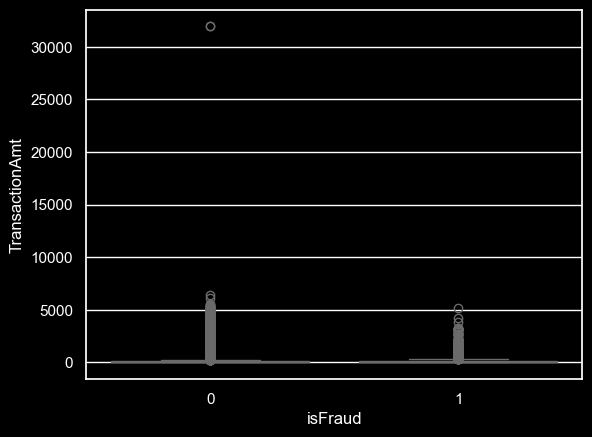

In [155]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=dftx)

<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

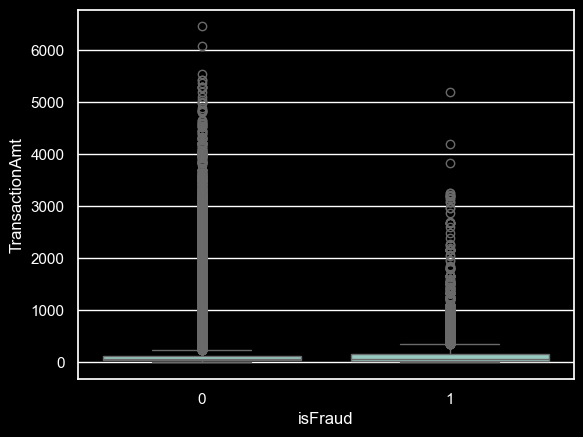

In [156]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=dftx[dftx['TransactionAmt'] < 7500])

In [151]:
dftx_fraudulent = dftx[dftx['isFraud']==1]
dftx_fraudulent['TransactionAmt'].describe()


count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64

In [152]:
dftx_fraudulent = dftx[dftx['isFraud']==0]
dftx_fraudulent['TransactionAmt'].describe()

count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [157]:
bins = [0, 50, 200, 1000, float('inf')]
labels = ['very low', 'low', 'medium', 'high']

binnedFeature = pd.cut(dftx['TransactionAmt'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
TransactionAmt,,
very low,0.961701,0.038299
low,0.970264,0.029736
medium,0.954233,0.045767
high,0.975368,0.024632


### Exploring features: TransactionAmt

My initial assumption was that TransactionAmt would not be a strong fraud indicator. After applying a box plot and looking the distribution for the fraudulent transactions and no fraudulent ones we can say:
* No nulls in this value
* There is no clear pattern in the distribution to identify a fraudulent transaction. For example, the distribution at 75% between both is fraud=161 vs non-fraud=120 and for 50% is fraud=75 vs non-fraud=68.5 which is a very slight difference. Same when we compare the mean 149.24 vs 134.51.
* There is no fraudulent transaction over 5191 in this dataset but this is not enough to set a production threshold because we only have 20663 fraudulent transactions over 569877 non-fraudulent ones.
* Splitting into 4 bins (very low=0-50, low=50-200, medium=200-1000, high>1000) only the medium amount with 4.5% is higher than the baseline (3.4%) but has no clear pattern.

**Decision**: We maintain the feature as numeric because it is going to give us information about the distribution.

In [158]:
dftx['TransactionDT'].isnull().sum()


np.int64(0)

In [159]:
dftx['TransactionDT'].describe()


count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [160]:
min_value = dftx['TransactionDT'].min()
max_value = dftx['TransactionDT'].max()
print(f"Min TransactionDT: { min_value/ (60*60*24):.1f} days")
print(f"Max TransactionDT: {max_value / (60*60*24):.1f} days")
print(f"Range: {(max_value - min_value) / (60*60*24):.1f} days")


Min TransactionDT: 1.0 days
Max TransactionDT: 183.0 days
Range: 182.0 days


In [164]:
bins = [0, 30, 60, 90, float('inf')]
labels = ['0-30 days', '30-60 days', '60-90 days', '> 90 days']
dftx['TransactionDTDays'] = dftx['TransactionDT'] / (60*60*24)
binnedFeature = pd.cut(dftx['TransactionDTDays'], bins=bins, labels=labels)
pd.crosstab(binnedFeature, dftx['isFraud'], normalize='index')

isFraud,0,1
TransactionDTDays,,
0-30 days,0.975238,0.024762
30-60 days,0.959627,0.040373
60-90 days,0.959681,0.040319
> 90 days,0.963690,0.036310


### Exploring features: TransactionDT

TransactionDt gives us an amount of seconds from an unknown reference date. We only know smaller values means older transactions. We changed to days to manage them clearly. Conclusions:
* No nulls in this feature
* Range of 182 days. We can use this value to split the dataset by time.
* After splitting into bins ('0-30 days', '30-60 days', '60-90 days', '> 90 days') we can see the oldest transactions (0-30 days) has a 2.4% of fraudulent that is less than the baseline (3.4%) and the biggest percentage is between 30 and 90 days (two bins combined) (4.03%) which is not a very high value.

**Decision**: We maintain the feature in days, and we can use it to split the dataset by time (60/20/20 - Train/Validation/Test) -> (109 days/36.4 days/36.4 days)

In [172]:
print(dfid.shape)
dfid.dtypes

(144233, 41)


TransactionID      int64
id_01            float64
id_02            float64
id_03            float64
id_04            float64
id_05            float64
id_06            float64
id_07            float64
id_08            float64
id_09            float64
id_10            float64
id_11            float64
id_12                str
id_13            float64
id_14            float64
id_15                str
id_16                str
id_17            float64
id_18            float64
id_19            float64
id_20            float64
id_21            float64
id_22            float64
id_23                str
id_24            float64
id_25            float64
id_26            float64
id_27                str
id_28                str
id_29                str
id_30                str
id_31                str
id_32            float64
id_33                str
id_34                str
id_35                str
id_36                str
id_37                str
id_38                str
DeviceType           str


### Exploring identity dataset

The new identity dataset has 144233 rows that is much less than the transaction dataset (590540). If we want to join both we have two options:
1) Apply a transaction left join identity and the data with no coincidence are set to null in the merged dataset. We finally will have 590540 rows.
2) Apply an inner join and the result will be a dataset with the coincidences. We are gonna lose a lot of data and finally get a 144233 rows dataset.

Taking into account the good amount of valid data in the transaction dataset, we don't want to lose this info, so we decide to use a left join

In [171]:
df_merged = dftx.merge(dfid, on='TransactionID', how='left')
df_merged.shape

(590540, 452)

In [179]:
df_merged['has_identity'] = df_merged['id_01'].notnull().astype(int)
pd.crosstab(df_merged['has_identity'], df_merged['isFraud'], normalize='index')

isFraud,0,1
has_identity,,
0,0.979061,0.020939
1,0.921530,0.078470


### Exploring features: 'has_identity'

We have created a new feature called 'has_identity' to check if rows with identity data has more fraud signal than others without identity. What we saw is that the rows with identity values has 7.8% vs 2.1% of fraud of 144.233 so we can consider to add this new feature as an additional binary one in the preprocessing stage.

In [183]:
df_merged['DeviceType'].isnull().sum()
temp = df_merged['DeviceType'].fillna('NaN_value')
print(pd.crosstab(temp, df_merged['isFraud'], normalize='index'))

df_merged['DeviceType'].value_counts()


isFraud            0         1
DeviceType                    
NaN_value   0.978983  0.021017
desktop     0.934785  0.065215
mobile      0.898338  0.101662


### Exploring features: DeviceType

The DeviceType gives us information whether the transaction was made using a mobile or desktop terminal. The findings are:
* A 10.1% of the mobile transactions are fraudulent from 55645 transactions. Much higher than the baseline (3.4%).
* A 6.5% of the desktop transactions are fraudulent from 85165 transactions.
* Due to this feature is coming from joining identity dataset into the transaction one, only ~24% of transactions have identity data, so it has a high null rate.
**Decision:** this feature is very useful because of the low cardinality. Proposed for one-hot encoding during the preprocessing.

In [194]:
df_merged['DeviceInfo'].value_counts()


DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
                               ...  
G8142                              1
G630-U251                          1
LG-K212                            1
LDN-LX3 Build/HUAWEILDN-LX3        1
Z955A                              1
Name: count, Length: 1786, dtype: int64

In [203]:
def extract_os(device_info):
    if pd.isna(device_info):
        return 'unknown'
    device_info = device_info.lower()
    if 'windows' in device_info:
        return 'windows'
    if 'android' in device_info or 'sm-' in device_info or 'ale-l23' in device_info or 'moto g' in device_info:
        return 'android'
    if 'ios' in device_info or 'iphone' in device_info or 'ipad' in device_info:
        return 'ios'
    if 'mac' in device_info:
        return 'mac'
    return 'other'

df_merged['DeviceOS'] = df_merged['DeviceInfo'].apply(extract_os)
print(df_merged['DeviceOS'].value_counts())
pd.crosstab(df_merged['DeviceOS'], df_merged['isFraud'], normalize='index')

DeviceOS
unknown    471874
windows     47775
other       24810
ios         19783
android     13725
mac         12573
Name: count, dtype: int64


isFraud,0,1
DeviceOS,,
android,0.879417,0.120583
ios,0.937269,0.062731
mac,0.977889,0.022111
other,0.907215,0.092785
unknown,0.974451,0.025549
windows,0.934464,0.065536


### Exploring features: DeviceInfo

The DeviceInfo gives us information about the OS. In an initial view we can group in android, ios, mac, windows and others. Others has different OS with not too much weight like linux. The summary is:
* android — 12%, high signal
* other — 9.3%, relevant signal
* ios and windows — ~6.5%, 2x of baseline
* mac and unknown — close to baseline
* Same as DeviceType and due to this feature is coming from joining identity dataset into the transaction one, only ~24% of transactions have identity data, so it has a high null rate.

**Decision:** This derived feature  (DeviceOS, created by grouping DeviceInfo values) seems to have clearer info than DeviceInfo. I recommend removing DeviceInfo and leave DeviceOS during the preprocessing.